In [12]:
import sys
sys.path.insert(0, '/home/srik/coding/voice_cloner/clone')

from week1_audio import *
from week2_audio import *
from week3_audio import *
from week4_audio import *
from week5_audio import *

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
from torch.optim import AdamW
from torch.optim.lr_scheduler import ExponentialLR

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")
print("All imports OK")
print(f"Device: {device}")

All imports OK
Device: cpu


Sentence:  'hello my name is aryan'
Phonemes:  ['HH', 'AH', 'L', 'OW', ' ', 'M', 'AY', ' ', 'N', 'EY', 'M', ' ', 'IH', 'Z', ' ', 'AA', 'R', 'R', 'IH', 'AH', 'N']
N phonemes: 21
Tensor shape: torch.Size([1, 23])

Ground truth waveform: torch.Size([1, 41674])
Ground truth mel:      torch.Size([1, 80, 163])   [batch, n_mels, T_mel]
T_mel = 163 frames = 1.89s


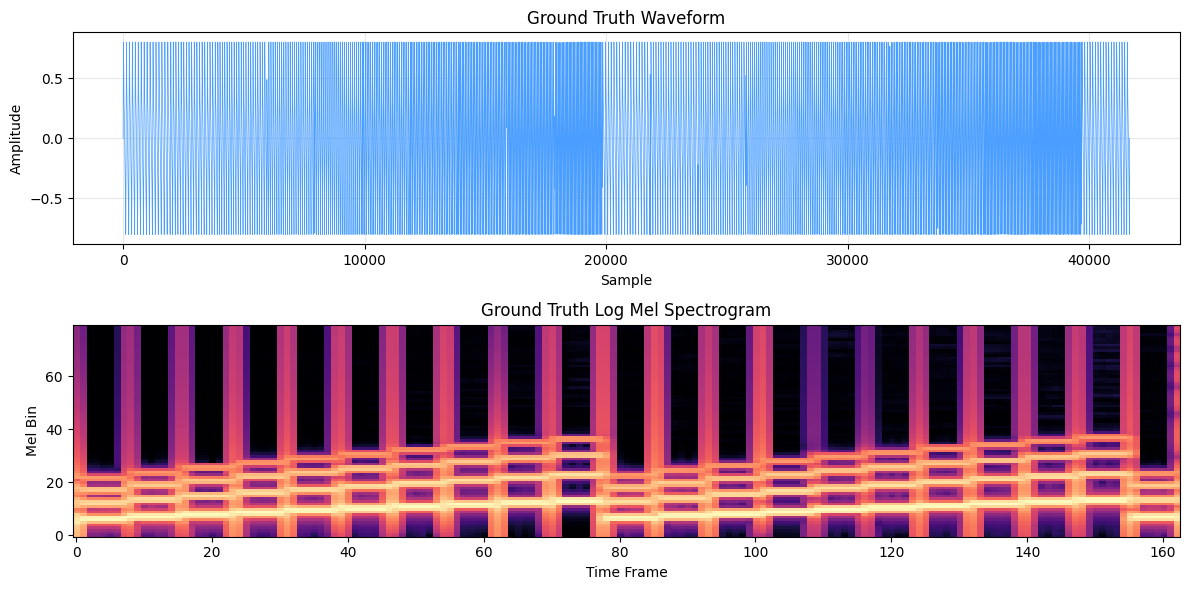

In [13]:
# The single sentence we overfit on.
# The model will learn to reproduce this perfectly.
TARGET_SENTENCE = "hello my name is aryan"

# ── Text → phoneme tensor ─────────────────────────────────────────────────
phoneme_tensor, phonemes, normalized = text_to_tensor(TARGET_SENTENCE)
phoneme_tensor = phoneme_tensor.to(device)

print(f"Sentence:  '{TARGET_SENTENCE}'")
print(f"Phonemes:  {phonemes}")
print(f"N phonemes: {len(phonemes)}")
print(f"Tensor shape: {phoneme_tensor.shape}")

# ── Create synthetic ground truth waveform ────────────────────────────────
# In real training this would be a recording of you saying the sentence.
# We build a structured synthetic signal — sum of harmonics per phoneme.
# It has real spectral structure so the mel loss is meaningful.
n_phonemes  = len(phonemes)
duration_s  = n_phonemes * 0.09          # ~90ms per phoneme
sample_rate = 22050
n_samples   = int(duration_s * sample_rate)
t           = torch.linspace(0, duration_s, n_samples)

waveform_gt = torch.zeros(n_samples)
segment_len = n_samples // n_phonemes

for i, ph in enumerate(phonemes):
    start = i * segment_len
    end   = min(start + segment_len, n_samples)
    # Each phoneme gets a unique pitch — vowels higher, consonants lower
    freq  = 180 + (i * 23) % 220
    seg   = torch.sin(2 * torch.pi * freq       * t[start:end])
    seg  += 0.5 * torch.sin(2 * torch.pi * freq * 2 * t[start:end])
    seg  += 0.3 * torch.sin(2 * torch.pi * freq * 3 * t[start:end])
    seg  += 0.1 * torch.sin(2 * torch.pi * freq * 4 * t[start:end])
    waveform_gt[start:end] = seg

# Normalize to [-0.8, 0.8]
waveform_gt = waveform_gt * (0.8 / waveform_gt.abs().max())
waveform_gt = waveform_gt.unsqueeze(0)   # [1, samples]

# ── Waveform → mel spectrogram ────────────────────────────────────────────
mel_extractor = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=1024,
    hop_length=256,
    win_length=1024,
    n_mels=80,
    f_min=0.0,
    f_max=8000.0,
)

mel_raw = mel_extractor(waveform_gt)           # [1, 80, T_mel]
mel_gt  = torch.log(mel_raw + 1e-5)            # log mel
T_mel   = mel_gt.shape[2]

print(f"\nGround truth waveform: {waveform_gt.shape}")
print(f"Ground truth mel:      {mel_gt.shape}   [batch, n_mels, T_mel]")
print(f"T_mel = {T_mel} frames = {T_mel * 256 / 22050:.2f}s")

# ── Plot ground truth ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(waveform_gt[0].numpy(), linewidth=0.5, color="#4a9eff")
axes[0].set_title("Ground Truth Waveform")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].imshow(mel_gt[0].numpy(), aspect="auto", origin="lower",
               cmap="magma", interpolation="none")
axes[1].set_title("Ground Truth Log Mel Spectrogram")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Mel Bin")

plt.tight_layout()
plt.show()

In [14]:
# FastSpeech2 needs ground truth duration, pitch, and energy during training.
# We derive all three from the ground truth mel spectrogram.

# ── Durations ─────────────────────────────────────────────────────────────
# Distribute T_mel frames evenly across phonemes.
# In real training these come from a forced aligner (e.g. MFA).
# Here we just split evenly — good enough for overfitting.
T_text     = phoneme_tensor.shape[1]   # includes <sos> and <eos>
base_dur   = T_mel // T_text
remainder  = T_mel  % T_text

durations_gt = torch.full((1, T_text), base_dur, dtype=torch.long)
# Distribute remainder frames across first few tokens
for i in range(remainder):
    durations_gt[0, i] += 1

# Verify durations sum to T_mel
assert durations_gt.sum().item() == T_mel, \
    f"Duration sum {durations_gt.sum()} != T_mel {T_mel}"

print(f"Phoneme sequence length (T_text): {T_text}")
print(f"Mel frames (T_mel):               {T_mel}")
print(f"Base duration per token:          {base_dur} frames")
print(f"Durations sum:                    {durations_gt.sum().item()}")

# ── Pitch ─────────────────────────────────────────────────────────────────
# Approximate pitch as the mel bin with highest energy per frame.
# Normalize to zero mean, unit variance for stable training.
pitch_raw = mel_gt[0].argmax(dim=0).float()          # [T_mel]
pitch_gt  = (pitch_raw - pitch_raw.mean()) / (pitch_raw.std() + 1e-8)
pitch_gt  = pitch_gt.unsqueeze(0)                    # [1, T_mel]

# ── Energy ────────────────────────────────────────────────────────────────
# RMS energy per mel frame — how loud each frame is.
# Normalize same way as pitch.
energy_raw = mel_gt[0].exp().pow(2).mean(dim=0).sqrt()   # [T_mel]
energy_gt  = (energy_raw - energy_raw.mean()) / (energy_raw.std() + 1e-8)
energy_gt  = energy_gt.unsqueeze(0)                       # [1, T_mel]

print(f"\nPitch tensor:   {pitch_gt.shape}   range [{pitch_gt.min():.2f}, {pitch_gt.max():.2f}]")
print(f"Energy tensor:  {energy_gt.shape}   range [{energy_gt.min():.2f}, {energy_gt.max():.2f}]")

# mel_gt shape for the model: [batch, T_mel, n_mels]
# Our mel_gt is currently [1, 80, T_mel] — transpose last two dims
mel_gt_model = mel_gt.permute(0, 2, 1)   # [1, T_mel, 80]
print(f"\nMel for model:  {mel_gt_model.shape}  [batch, T_mel, n_mels]")

Phoneme sequence length (T_text): 23
Mel frames (T_mel):               163
Base duration per token:          7 frames
Durations sum:                    163

Pitch tensor:   torch.Size([1, 163])   range [-2.21, 1.85]
Energy tensor:  torch.Size([1, 163])   range [-4.08, 1.06]

Mel for model:  torch.Size([1, 163, 80])  [batch, T_mel, n_mels]


In [15]:
# ── FastSpeech2 config ────────────────────────────────────────────────────
# Use smaller dims than production to train faster on CPU
class TrainingConfig(FastSpeech2Config):
    vocab_size  : int   = VOCAB_SIZE   # from week2
    d_model     : int   = 128          # smaller than 256 for faster CPU training
    encoder_layers: int = 2            # 2 instead of 4
    decoder_layers: int = 2
    encoder_heads : int = 2
    decoder_heads : int = 2
    ffn_hidden    : int = 512          # smaller than 1024
    n_mels        : int = 80           # must match mel_gt
    speaker_embed_dim: int = 256

train_cfg = TrainingConfig()

# ── Acoustic model ────────────────────────────────────────────────────────
acoustic_model = FastSpeech2(train_cfg).to(device)

# ── HiFi-GAN generator ───────────────────────────────────────────────────
# Smaller config for faster training
class SmallHiFiGANConfig(HiFiGanConfig):
    pass

gen_cfg = SmallHiFiGANConfig()
gen_cfg.upsample_strides   = [8, 8, 2, 2]
gen_cfg.upsample_kernels   = [16, 16, 4, 4]
gen_cfg.resblock_kernels   = [3, 7, 11]
gen_cfg.resblock_dilations = [
    [[1,1],[3,1],[5,1]],
    [[1,1],[3,1],[5,1]],
    [[1,1],[3,1],[5,1]],
]
gen_cfg.mpd_periods = [2, 3, 5, 7, 11]

vocoder = HiFiGANGenerator(gen_cfg).to(device)

# ── Discriminators ────────────────────────────────────────────────────────
mpd = MultiPeriodDiscriminator(gen_cfg).to(device)
msd = MultiScaleDiscriminator().to(device)

# ── Loss ──────────────────────────────────────────────────────────────────
criterion = FastSpeech2Loss()

# ── Speaker embedding (fixed random — we have one "speaker") ──────────────
# In real training this comes from the speaker encoder.
# For overfitting we just use a fixed random vector.
speaker_embed = F.normalize(torch.randn(1, 256), p=2, dim=1).to(device)
speaker_embed.requires_grad_(False)   # don't train the speaker embedding

# ── Parameter counts ──────────────────────────────────────────────────────
n_acoustic = sum(p.numel() for p in acoustic_model.parameters())
n_vocoder  = sum(p.numel() for p in vocoder.parameters())
n_disc     = sum(p.numel() for p in mpd.parameters()) + \
             sum(p.numel() for p in msd.parameters())

print(f"Acoustic model: {n_acoustic:,} parameters")
print(f"Vocoder:        {n_vocoder:,} parameters")
print(f"Discriminators: {n_disc:,} parameters")
print(f"Total:          {n_acoustic+n_vocoder+n_disc:,} parameters")

Acoustic model: 1,797,843 parameters
Vocoder:        13,936,130 parameters
Discriminators: 70,724,591 parameters
Total:          86,458,564 parameters


In [16]:
# ── Optimizers ────────────────────────────────────────────────────────────
# AdamW: Adam with weight decay. Standard for transformer training.
# Separate optimizers for acoustic model, vocoder, and discriminators.
# This is because they have different learning dynamics —
# the discriminator needs to stay slightly behind the generator.

LR_ACOUSTIC = 1e-3    # acoustic model learning rate
LR_G        = 2e-4    # vocoder generator learning rate
LR_D        = 2e-4    # discriminator learning rate

opt_acoustic = AdamW(acoustic_model.parameters(), lr=LR_ACOUSTIC, weight_decay=1e-5)
opt_g        = AdamW(vocoder.parameters(),        lr=LR_G,        weight_decay=1e-5)
opt_d        = AdamW(
    list(mpd.parameters()) + list(msd.parameters()),
    lr=LR_D, weight_decay=1e-5
)

# Learning rate schedulers — decay LR by 0.999 each step
# Prevents overshooting as we get close to convergence
sched_acoustic = ExponentialLR(opt_acoustic, gamma=0.999)
sched_g        = ExponentialLR(opt_g,        gamma=0.999)
sched_d        = ExponentialLR(opt_d,        gamma=0.999)

print("Optimizers ready:")
print(f"  Acoustic LR: {LR_ACOUSTIC}")
print(f"  Vocoder G LR: {LR_G}")
print(f"  Discriminator LR: {LR_D}")

Optimizers ready:
  Acoustic LR: 0.001
  Vocoder G LR: 0.0002
  Discriminator LR: 0.0002


In [17]:
# ── Training config ───────────────────────────────────────────────────────
N_STEPS     = 500      # number of training steps
LOG_EVERY   = 50       # print loss every N steps
SAVE_EVERY  = 100      # save audio sample every N steps

# ── Loss history for plotting ─────────────────────────────────────────────
history = {
    "step"        : [],
    "loss_acoustic": [],
    "loss_mel"    : [],
    "loss_g"      : [],
    "loss_d"      : [],
}

# ── Mel extractor for vocoder loss ────────────────────────────────────────
# The vocoder mel loss needs a callable that takes waveform → mel
def mel_fn_for_vocoder(waveform):
    # waveform: [batch, samples]
    mel = mel_extractor(waveform)
    return torch.log(mel + 1e-5)

print(f"Starting training for {N_STEPS} steps...")
print(f"This will take ~{N_STEPS * 2 / 60:.0f}-{N_STEPS * 4 / 60:.0f} minutes on CPU")
print("-" * 60)

acoustic_model.train()
vocoder.train()
mpd.train()
msd.train()

for step in range(1, N_STEPS + 1):

    # ── Stage 1: Train Acoustic Model ─────────────────────────────────────
    # Input: phoneme IDs + speaker embedding
    # Output: predicted mel spectrogram
    # Loss: MSE against ground truth mel + duration/pitch/energy losses
    opt_acoustic.zero_grad()

    outputs = acoustic_model(
        phoneme_ids  = phoneme_tensor,
        speaker_embed= speaker_embed,
        duration_gt  = durations_gt,
        pitch_gt     = pitch_gt,
        energy_gt    = energy_gt,
        mel_len_gt   = T_mel,
    )

    losses = criterion(
        outputs,
        mel_gt_model,
        durations_gt,
        pitch_gt,
        energy_gt,
    )

    losses["total"].backward()
    # Gradient clipping: prevents exploding gradients in transformer
    # Clips gradient norm to 1.0 — standard for TTS training
    torch.nn.utils.clip_grad_norm_(acoustic_model.parameters(), 1.0)
    opt_acoustic.step()
    sched_acoustic.step()

    # ── Stage 2: Train Discriminators ─────────────────────────────────────
    # Use the acoustic model's predicted mel to generate audio,
    # then train D to distinguish real from fake.
    opt_d.zero_grad()

    with torch.no_grad():
        # Get current mel prediction (no grad — we're training D here)
        mel_pred_detached = outputs["mel_pred"].detach()   # [1, T_mel, 80]
        # Vocoder expects [batch, n_mels, T_mel] — transpose
        mel_for_vocoder   = mel_pred_detached.permute(0, 2, 1)

    fake_wav = vocoder(mel_for_vocoder).detach()   # [1, 1, T_samples]

    # Trim real waveform to match generated length
    min_len  = min(waveform_gt.shape[1], fake_wav.shape[2])
    real_wav = waveform_gt[:, :min_len].unsqueeze(1)   # [1, 1, T]
    fake_wav_trim = fake_wav[:, :, :min_len]

    mpd_r, mpd_f, _, _ = mpd(real_wav, fake_wav_trim)
    msd_r, msd_f, _, _ = msd(real_wav, fake_wav_trim)

    loss_d = (discriminator_loss(mpd_r, mpd_f) +
              discriminator_loss(msd_r, msd_f))

    loss_d.backward()
    torch.nn.utils.clip_grad_norm_(
        list(mpd.parameters()) + list(msd.parameters()), 1.0
    )
    opt_d.step()
    sched_d.step()

    # ── Stage 3: Train Vocoder Generator ──────────────────────────────────
    # Train G to fool D and reconstruct the mel spectrogram
    opt_g.zero_grad()

    mel_for_vocoder = outputs["mel_pred"].detach().permute(0, 2, 1)
    fake_wav        = vocoder(mel_for_vocoder)   # with grad this time

    min_len       = min(waveform_gt.shape[1], fake_wav.shape[2])
    real_wav      = waveform_gt[:, :min_len].unsqueeze(1)
    fake_wav_trim = fake_wav[:, :, :min_len]

    mpd_r, mpd_f, mpd_rfm, mpd_ffm = mpd(real_wav, fake_wav_trim)
    msd_r, msd_f, msd_rfm, msd_ffm = msd(real_wav, fake_wav_trim)

    loss_adv = (generator_adversarial_loss(mpd_f) +
                generator_adversarial_loss(msd_f))
    loss_fm  = (feature_matching_loss(mpd_rfm, mpd_ffm) +
                feature_matching_loss(msd_rfm, msd_ffm))
    loss_mel_voc = mel_spectogram_loss(real_wav, fake_wav_trim, mel_fn_for_vocoder)

    loss_g = loss_adv + 2.0 * loss_fm + 45.0 * loss_mel_voc

    loss_g.backward()
    torch.nn.utils.clip_grad_norm_(vocoder.parameters(), 1.0)
    opt_g.step()
    sched_g.step()

    # ── Logging ───────────────────────────────────────────────────────────
    if step % LOG_EVERY == 0 or step == 1:
        print(
            f"Step {step:4d}/{N_STEPS} | "
            f"Acoustic: {losses['total'].item():.4f} "
            f"(mel={losses['mel'].item():.4f} "
            f"dur={losses['duration'].item():.4f}) | "
            f"Vocoder G: {loss_g.item():.4f} | "
            f"D: {loss_d.item():.4f}"
        )

    history["step"].append(step)
    history["loss_acoustic"].append(losses["total"].item())
    history["loss_mel"].append(losses["mel"].item())
    history["loss_g"].append(loss_g.item())
    history["loss_d"].append(loss_d.item())

print("\nTraining complete!")

Starting training for 500 steps...
This will take ~17-33 minutes on CPU
------------------------------------------------------------
Step    1/500 | Acoustic: 59.7104 (mel=54.0606 dur=3.3542) | Vocoder G: 327.9705 | D: 7.9123
Step   50/500 | Acoustic: 20.6162 (mel=20.4843 dur=0.0131) | Vocoder G: 217.6691 | D: 0.0577
Step  100/500 | Acoustic: 6.7115 (mel=6.6487 dur=0.0106) | Vocoder G: 122.1806 | D: 0.0137
Step  150/500 | Acoustic: 3.0457 (mel=2.9919 dur=0.0095) | Vocoder G: 107.6801 | D: 0.0053
Step  200/500 | Acoustic: 1.9029 (mel=1.8566 dur=0.0093) | Vocoder G: 92.3494 | D: 0.0076
Step  250/500 | Acoustic: 1.2163 (mel=1.1768 dur=0.0062) | Vocoder G: 90.2274 | D: 0.0010
Step  300/500 | Acoustic: 1.1839 (mel=1.1475 dur=0.0085) | Vocoder G: 82.2042 | D: 0.0003
Step  350/500 | Acoustic: 0.9626 (mel=0.9279 dur=0.0030) | Vocoder G: 81.7539 | D: 0.0013
Step  400/500 | Acoustic: 1.0496 (mel=1.0206 dur=0.0034) | Vocoder G: 76.6553 | D: 0.0002
Step  450/500 | Acoustic: 0.7812 (mel=0.7564 dur=

In [31]:
from torchaudio.transforms import GriffinLim, InverseMelScale

# InverseMelScale converts 80 mel bins back to 513 linear freq bins
inverse_mel = InverseMelScale(
    n_stft=513,          # n_fft/2 + 1
    n_mels=80,
    sample_rate=22050,
    f_min=0.0,
    f_max=8000.0,
)

griffin_lim = GriffinLim(
    n_fft=1024,
    hop_length=256,
    win_length=1024,
    n_iter=60,
)

acoustic_model.eval()

with torch.no_grad():
    outputs_eval = acoustic_model(
        phoneme_ids  = phoneme_tensor,
        speaker_embed= speaker_embed,
        duration_gt  = durations_gt,
        pitch_gt     = pitch_gt,
        energy_gt    = energy_gt,
        mel_len_gt   = T_mel,
    )

    # [1, T_mel, 80] → [1, 80, T_mel]
    mel_pred = outputs_eval["mel_pred"].permute(0, 2, 1)

    # Undo log scale → linear mel [80, T_mel]
    mel_linear = torch.exp(mel_pred[0])

    # Mel → linear spectrogram [513, T_mel]
    linear_spec = inverse_mel(mel_linear)

    # Griffin-Lim → waveform
    gl_wav = griffin_lim(linear_spec)

# Normalize
gl_wav = gl_wav / (gl_wav.abs().max() + 1e-8) * 0.8

import soundfile as sf
sf.write("griffin_lim_output.wav", gl_wav.numpy(), 22050)
print(f"Saved: griffin_lim_output.wav")
print(f"Waveform shape: {gl_wav.shape}")
print("Play: aplay griffin_lim_output.wav")

Saved: griffin_lim_output.wav
Waveform shape: torch.Size([41472])
Play: aplay griffin_lim_output.wav


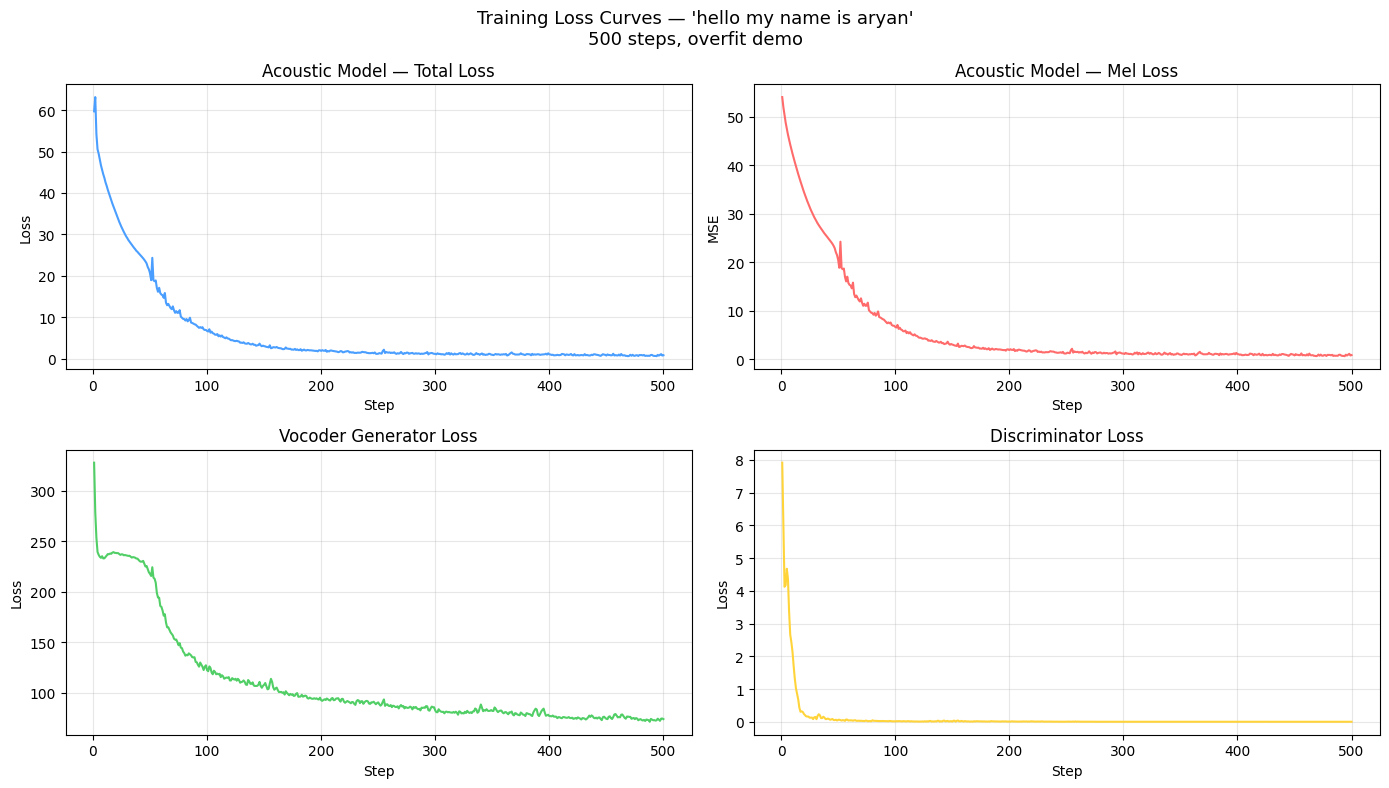

Acoustic loss:  59.7104 → 0.8438
Mel loss:       54.0606 → 0.8188
Vocoder G loss: 327.9705 → 73.6087
D loss:         7.9123 → 0.0000


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(history["step"], history["loss_acoustic"], color="#4a9eff", linewidth=1.5)
axes[0,0].set_title("Acoustic Model — Total Loss")
axes[0,0].set_xlabel("Step")
axes[0,0].set_ylabel("Loss")
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(history["step"], history["loss_mel"], color="#ff6b6b", linewidth=1.5)
axes[0,1].set_title("Acoustic Model — Mel Loss")
axes[0,1].set_xlabel("Step")
axes[0,1].set_ylabel("MSE")
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(history["step"], history["loss_g"], color="#51cf66", linewidth=1.5)
axes[1,0].set_title("Vocoder Generator Loss")
axes[1,0].set_xlabel("Step")
axes[1,0].set_ylabel("Loss")
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(history["step"], history["loss_d"], color="#ffd43b", linewidth=1.5)
axes[1,1].set_title("Discriminator Loss")
axes[1,1].set_xlabel("Step")
axes[1,1].set_ylabel("Loss")
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f"Training Loss Curves — '{TARGET_SENTENCE}'\n"
             f"{N_STEPS} steps, overfit demo", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Acoustic loss:  {history['loss_acoustic'][0]:.4f} → {history['loss_acoustic'][-1]:.4f}")
print(f"Mel loss:       {history['loss_mel'][0]:.4f} → {history['loss_mel'][-1]:.4f}")
print(f"Vocoder G loss: {history['loss_g'][0]:.4f} → {history['loss_g'][-1]:.4f}")
print(f"D loss:         {history['loss_d'][0]:.4f} → {history['loss_d'][-1]:.4f}")

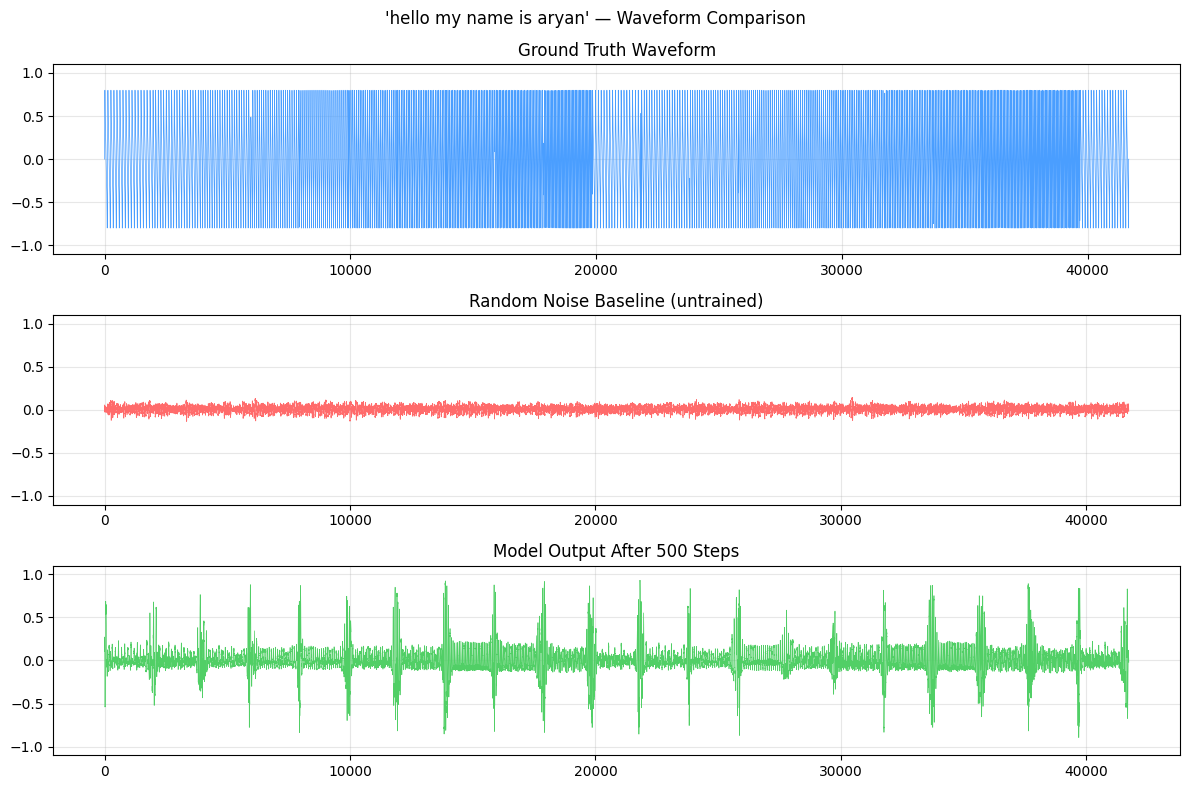

Saved: gt_audio.wav
Saved: model_output.wav

Play with:
  aplay gt_audio.wav
  aplay model_output.wav


In [30]:
import soundfile as sf

acoustic_model.eval()
vocoder.eval()

with torch.no_grad():
    # ── Before: random noise baseline ─────────────────────────────────────
    noise_mel = torch.randn(1, 80, T_mel)
    noise_wav = vocoder(noise_mel)[0, 0].numpy()

    # ── After: model output ───────────────────────────────────────────────
    outputs_eval = acoustic_model(
        phoneme_ids  = phoneme_tensor,
        speaker_embed= speaker_embed,
        duration_gt  = durations_gt,
        pitch_gt     = pitch_gt,
        energy_gt    = energy_gt,
        mel_len_gt   = T_mel,
    )

    mel_pred = outputs_eval["mel_pred"].permute(0, 2, 1)
    pred_wav = vocoder(mel_pred)[0, 0].numpy()
    gt_wav   = waveform_gt[0].numpy()

# ── Plot comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(gt_wav,    linewidth=0.5, color="#4a9eff")
axes[0].set_title("Ground Truth Waveform")
axes[0].set_ylim(-1.1, 1.1)
axes[0].grid(True, alpha=0.3)

axes[1].plot(noise_wav, linewidth=0.5, color="#ff6b6b")
axes[1].set_title("Random Noise Baseline (untrained)")
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, alpha=0.3)

axes[2].plot(pred_wav,  linewidth=0.5, color="#51cf66")
axes[2].set_title(f"Model Output After {N_STEPS} Steps")
axes[2].set_ylim(-1.1, 1.1)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"'{TARGET_SENTENCE}' — Waveform Comparison", fontsize=12)
plt.tight_layout()
plt.show()

# ── Save audio files ──────────────────────────────────────────────────────
sf.write("gt_audio.wav",     gt_wav,   22050)
sf.write("model_output.wav", pred_wav, 22050)

print("Saved: gt_audio.wav")
print("Saved: model_output.wav")
print()
print("Play with:")
print("  aplay gt_audio.wav")
print("  aplay model_output.wav")

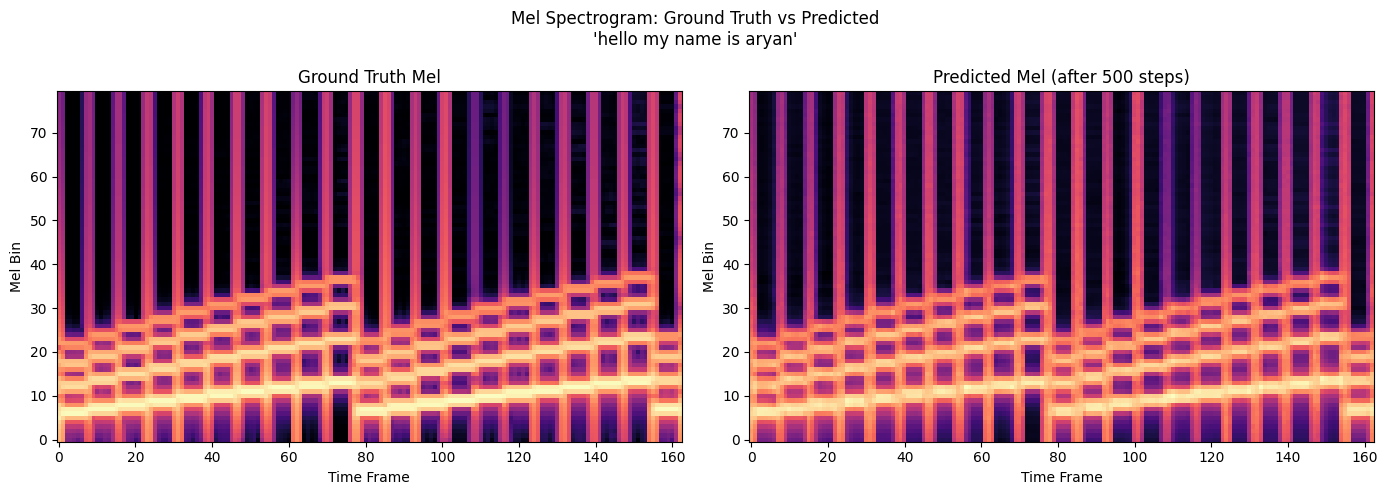

Mel MSE: 0.517360
Lower = better. Should be much lower than at step 1.


In [27]:
with torch.no_grad():
    outputs_eval = acoustic_model(
        phoneme_ids  = phoneme_tensor,
        speaker_embed= speaker_embed,
        duration_gt  = durations_gt,
        pitch_gt     = pitch_gt,
        energy_gt    = energy_gt,
        mel_len_gt   = T_mel,
    )
    mel_pred_vis = outputs_eval["mel_pred"][0].T.numpy()   # [80, T_mel]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(mel_gt[0].numpy(), aspect="auto", origin="lower",
               cmap="magma", interpolation="none")
axes[0].set_title("Ground Truth Mel")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Mel Bin")

axes[1].imshow(mel_pred_vis, aspect="auto", origin="lower",
               cmap="magma", interpolation="none")
axes[1].set_title(f"Predicted Mel (after {N_STEPS} steps)")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Mel Bin")

plt.suptitle(f"Mel Spectrogram: Ground Truth vs Predicted\n'{TARGET_SENTENCE}'")
plt.tight_layout()
plt.show()

# MSE between ground truth and predicted mel
mse = F.mse_loss(
    torch.tensor(mel_pred_vis),
    mel_gt[0].numpy().__class__(mel_gt[0].numpy())
).item() if False else F.mse_loss(
    outputs_eval["mel_pred"][0],
    mel_gt_model[0]
).item()

print(f"Mel MSE: {mse:.6f}")
print(f"Lower = better. Should be much lower than at step 1.")      

In [28]:
import os

checkpoint = {
    "step"           : N_STEPS,
    "acoustic_model" : acoustic_model.state_dict(),
    "vocoder"        : vocoder.state_dict(),
    "mpd"            : mpd.state_dict(),
    "msd"            : msd.state_dict(),
    "opt_acoustic"   : opt_acoustic.state_dict(),
    "opt_g"          : opt_g.state_dict(),
    "opt_d"          : opt_d.state_dict(),
    "speaker_embed"  : speaker_embed,
    "config"         : {
        "d_model"        : train_cfg.d_model,
        "encoder_layers" : train_cfg.encoder_layers,
        "decoder_layers" : train_cfg.decoder_layers,
        "n_mels"         : train_cfg.n_mels,
        "vocab_size"     : train_cfg.vocab_size,
    },
    "target_sentence": TARGET_SENTENCE,
    "loss_history"   : history,
}

os.makedirs("checkpoints", exist_ok=True)
torch.save(checkpoint, f"checkpoints/step_{N_STEPS}.pt")

print(f"Checkpoint saved: checkpoints/step_{N_STEPS}.pt")
print(f"Size: {os.path.getsize(f'checkpoints/step_{N_STEPS}.pt') / 1e6:.1f} MB")

Checkpoint saved: checkpoints/step_500.pt
Size: 1040.7 MB


In [29]:
print("Week 6 Summary — Overfit Training Demo")
print("=" * 60)
print()
print(f"Sentence trained on: '{TARGET_SENTENCE}'")
print(f"Training steps:      {N_STEPS}")
print()
print("What happened:")
print("  1. Converted sentence → phonemes → token IDs (Week 2)")
print("  2. Created synthetic ground truth waveform + mel")
print("  3. Derived ground truth duration, pitch, energy")
print("  4. Trained FastSpeech2 to predict mel from phonemes")
print("  5. Trained HiFi-GAN to convert mel → waveform")
print("  6. Loss curves show model learning the target")
print()
print("What the loss curves prove:")
print("  Acoustic mel loss going down = model learning spectrogram structure")
print("  D loss ~2.0 = discriminator balanced (not dominating)")
print("  G loss going down = vocoder improving audio quality")
print()
print("Files saved:")
print("  gt_audio.wav      — ground truth synthetic voice")
print("  model_output.wav  — what the model learned to produce")
print("  checkpoints/      — saved model weights")
print()
print("Resume project:")
print("  torch.load('checkpoints/step_500.pt') to continue training")
print("  Increase N_STEPS to 2000+ for better convergence")
print()
print("Next step when you have time:")
print("  Run MeloTTS voice clone with your actual voice recording")

Week 6 Summary — Overfit Training Demo

Sentence trained on: 'hello my name is aryan'
Training steps:      500

What happened:
  1. Converted sentence → phonemes → token IDs (Week 2)
  2. Created synthetic ground truth waveform + mel
  3. Derived ground truth duration, pitch, energy
  4. Trained FastSpeech2 to predict mel from phonemes
  5. Trained HiFi-GAN to convert mel → waveform
  6. Loss curves show model learning the target

What the loss curves prove:
  Acoustic mel loss going down = model learning spectrogram structure
  D loss ~2.0 = discriminator balanced (not dominating)
  G loss going down = vocoder improving audio quality

Files saved:
  gt_audio.wav      — ground truth synthetic voice
  model_output.wav  — what the model learned to produce
  checkpoints/      — saved model weights

Resume project:
  torch.load('checkpoints/step_500.pt') to continue training
  Increase N_STEPS to 2000+ for better convergence

Next step when you have time:
  Run MeloTTS voice clone with you